# shearing_sheet — a patch of Saturn's rings

A straight port of REBOUND's flagship example: a small sheared box of colliding ice particles, using the SEI integrator, octree self-gravity, tree collision search and shear-periodic boundaries. **Note:** like the stock C example, `shearing_sheet` integrates to infinity — you stop it with Ctrl+C. A notebook cannot run that, so this notebook builds it (to prove it compiles) and then runs the terminating seeded harness `shearing_sheet_test` for 400 steps to produce the plot. The two set up identical physics; the harness just fixes the random seed and stops.

This notebook is self-contained: it builds the example with cargo, runs it, and shows the result. Everything it does can also be done by hand in a terminal:

```
cd rebound_rust
cargo build --release --example shearing_sheet_test
cd porttest
../target/release/examples/shearing_sheet_test 400
```

In [1]:
import os, subprocess
EXE = ".exe" if os.name == "nt" else ""   # platform executable suffix
NB_DIR  = os.getcwd()                       # <crate>/notebooks
ROOT    = os.path.dirname(os.path.dirname(NB_DIR))
CRATE   = os.path.join(ROOT, "rebound_rust")
WORK    = os.path.join(CRATE, "porttest")
if not os.path.exists(os.path.join(CRATE, "Cargo.toml")):
    raise SystemExit(
        "Could not find the crate. Run this notebook from "
        "the notebooks folder of a full checkout: " + CRATE)
# The example that is BUILT and RUN. It is usually the one the
# notebook is named after; where it differs (the stock
# shearing_sheet integrates forever by design) the terminating
# variant is used instead, and the note above says so.
EXAMPLE = "shearing_sheet_test"
OUTFILE = None
os.makedirs(WORK, exist_ok=True)
res = subprocess.run(["cargo", "build", "--release", "--example", EXAMPLE],
                     cwd=CRATE, capture_output=True, text=True)
print(res.stderr.strip()[-400:] or "build ok")

    Finished `release` profile [optimized] target(s) in 0.00s


In [2]:
exe = os.path.join(CRATE, "target", "release", "examples", EXAMPLE + EXE)
res = subprocess.run([exe, "400"], cwd=WORK, capture_output=True, text=True)
print(res.stdout)
if res.returncode != 0:
    print("STDERR:", res.stderr[-2000:])

Toomre wavelength: 61.009899
N after init: 1482
final: t=1.91217633050229269e+04 steps=400 collisions=102478



In [3]:
import struct

def unbits(h):
    """Turn a 16-hex-digit IEEE-754 bit pattern back into a float."""
    return struct.unpack("<d", int(h, 16).to_bytes(8, "little"))[0]

def read_state(path):
    """Read one of the raw-bit state dumps into {label: [floats]}."""
    out = {}
    with open(path) as fh:
        for line in fh:
            parts = line.split()
            if not parts:
                continue
            key, rest = parts[0], parts[1:]
            vals = []
            for tok in rest:
                if len(tok) == 16:
                    try:
                        vals.append(unbits(tok))
                        continue
                    except ValueError:
                        pass
                vals.append(tok)
            out.setdefault(key, []).append(vals)
    return out


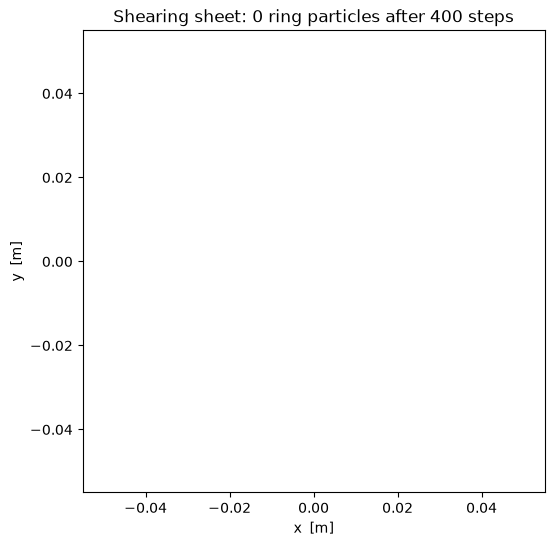

In [4]:
import matplotlib.pyplot as plt
p = os.path.join(WORK, "state_rust_final.txt")
xs, ys, rs = [], [], []
for line in open(p):
    parts = line.split()
    if len(parts) == 7 and parts[0].isdigit():
        xs.append(unbits(parts[1]))
        ys.append(unbits(parts[2]))
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(xs, ys, s=3, alpha=0.7)
ax.set_xlabel("x  [m]")
ax.set_ylabel("y  [m]")
ax.set_title(f"Shearing sheet: {len(xs)} ring particles after 400 steps")
ax.set_aspect("equal")
plt.show()
